## Instalasi Library

In [1]:
!pip install PySastrawi imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 6.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df_latih = pd.read_csv('Data_latih.csv')
df_uji   = pd.read_csv('Data_uji.csv')

Saving Data_latih.csv to Data_latih.csv
Saving Data_uji.csv to Data_uji.csv


In [3]:
df_latih.head(5)

,ID,label,tanggal,judul,narasi,nama file gambar
0,71,1,17-Aug-20,Pemakaian Masker Menyebabkan Penyakit Legionna...,A caller to a radio talk show recently shared ...,71.jpg
1,461,1,17-Jul-20,Instruksi Gubernur Jateng tentang penilangan ...,Yth.Seluruh Anggota Grup Sesuai Instruksi Gube...,461.png
2,495,1,13-Jul-20,Foto Jim Rohn: Jokowi adalah presiden terbaik ...,Jokowi adalah presiden terbaik dlm sejarah ban...,495.png
3,550,1,8-Jul-20,"ini bukan politik, tapi kenyataan Pak Jokowi b...","Maaf Mas2 dan Mbak2, ini bukan politik, tapi k...",550.png
4,681,1,24-Jun-20,Foto Kadrun kalo lihat foto ini panas dingin,Kadrun kalo lihat foto ini panas dingin . .,681.jpg


In [4]:
# Cek tipe data dan missing value
df_latih.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4231 entries, 0 to 4230
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                4231 non-null   int64 
 1   label             4231 non-null   int64 
 2   tanggal           4231 non-null   object
 3   judul             4231 non-null   object
 4   narasi            4231 non-null   object
 5   nama file gambar  4231 non-null   object
dtypes: int64(2), object(4)
memory usage: 198.5+ KB


In [5]:
# Cek distribusi label: 1 = Hoaks, 0 = Valid
df_latih['label'].value_counts()

,count
label,
1,3465
0,766


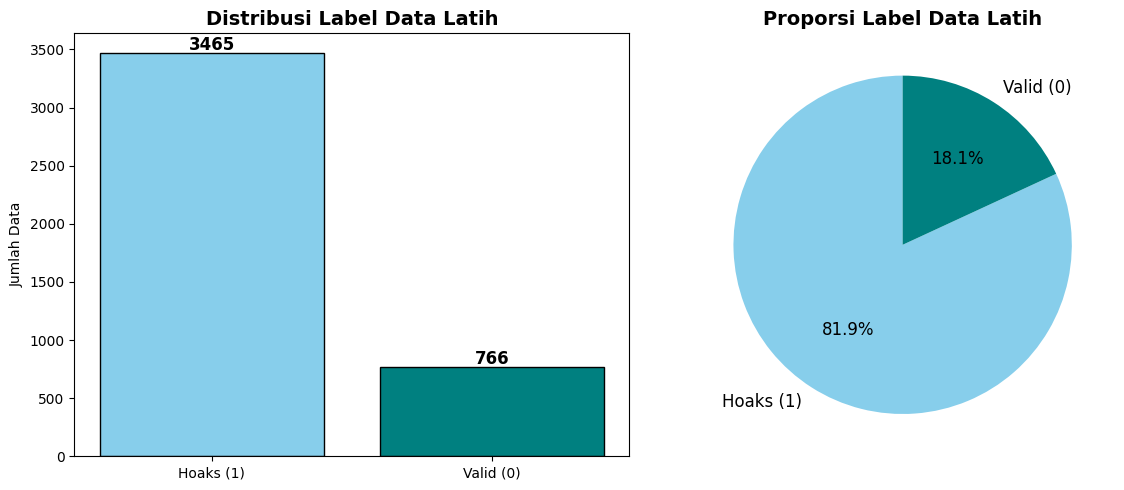

In [6]:
import matplotlib.pyplot as plt

# Visualisasi persebaran kelas untuk melihat class imbalance
label_counts = df_latih['label'].value_counts()
fig, axes   = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Hoaks (1)', 'Valid (0)'], label_counts.values,
            color=['skyblue', 'teal'], edgecolor='black')
axes[0].set_title('Distribusi Label Data Latih', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(label_counts.values,
            labels=['Hoaks (1)', 'Valid (0)'],
            colors=['skyblue', 'teal'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Label Data Latih', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

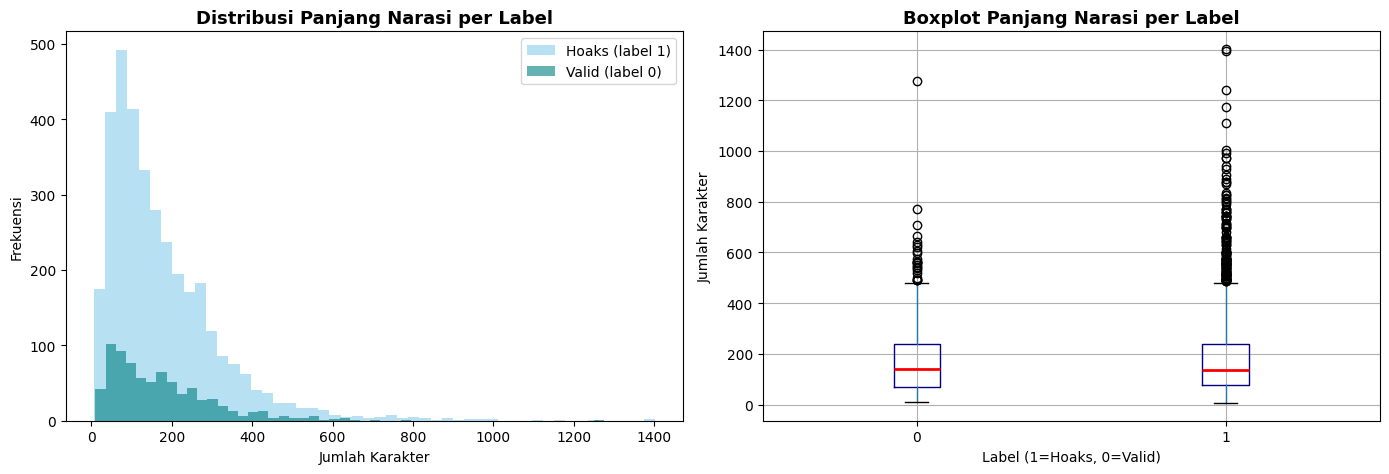

In [7]:
# Tambah kolom panjang narasi untuk melihat perbedaan karakteristik teks antar kelas

df_latih['panjang_narasi'] = df_latih['narasi'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, nama in zip([1, 0], ['skyblue', 'teal'], ['Hoaks', 'Valid']):
    data = df_latih[df_latih['label'] == label]['panjang_narasi']
    axes[0].hist(data, bins=50, alpha=0.6, color=color, label=f'{nama} (label {label})')

axes[0].set_title('Distribusi Panjang Narasi per Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

df_latih.boxplot(column='panjang_narasi', by='label', ax=axes[1],
                 boxprops=dict(color='navy'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Panjang Narasi per Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label (1=Hoaks, 0=Valid)')
axes[1].set_ylabel('Jumlah Karakter')
plt.suptitle('')

plt.tight_layout()
plt.savefig('panjang_narasi.png', dpi=150, bbox_inches='tight')
plt.show()

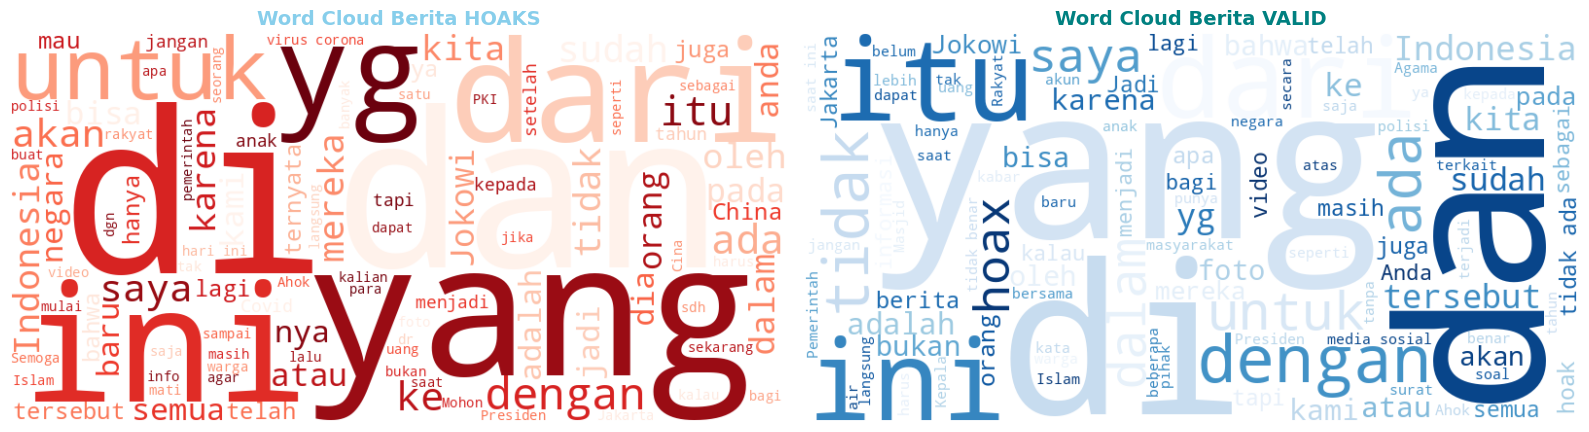

In [8]:
from wordcloud import WordCloud

# Visualisasi kata yang paling sering muncul di masing-masing kelas
teks_hoaks = ' '.join(df_latih[df_latih['label'] == 1]['narasi'].astype(str).tolist())
teks_valid = ' '.join(df_latih[df_latih['label'] == 0]['narasi'].astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_hoaks = WordCloud(width=800, height=400, background_color='white',
                     colormap='Reds', max_words=100).generate(teks_hoaks)
axes[0].imshow(wc_hoaks, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud Berita HOAKS', fontsize=14, fontweight='bold', color='skyblue')

wc_valid = WordCloud(width=800, height=400, background_color='white',
                     colormap='Blues', max_words=100).generate(teks_valid)
axes[1].imshow(wc_valid, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud Berita VALID', fontsize=14, fontweight='bold', color='teal')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Hasil Eksplorasi Data (EDA)
- Distribusi kelas menunjukkan ketidakseimbangan (3465 hoaks vs 766 valid).
- Panjang narasi hoaks cenderung lebih pendek.
- Word cloud menunjukkan kata-kata khas masing-masing kelas.

In [9]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('indonesian'))
stop_words.update(stopwords.words('english'))

custom_stopwords = {
    'yg', 'tdk', 'dgn', 'utk', 'krn', 'sdh', 'blm', 'jg', 'ny',
    'nya', 'saja', 'aja', 'deh', 'dong', 'nih', 'loh', 'lah',
    'mah', 'ya', 'yuk', 'wah', 'oh', 'ah', 'eh', 'iya', 'gak',
    'ga', 'nggak', 'enggak', 'gitu', 'gini', 'gimana', 'gt',
    'tp', 'jd', 'kl', 'klo', 'kalo', 'bgt', 'banget', 'emg',
    'emang', 'memang', 'juga', 'sudah', 'belum', 'bisa', 'akan',
    'ada', 'bagi', 'para', 'bila', 'maka', 'saat', 'pun'
}
stop_words.update(custom_stopwords)

def bersihkan_teks(teks):
    teks   = str(teks)
    teks   = teks.lower()
    teks   = re.sub(r'http\S+|www\S+', '', teks)
    teks   = re.sub(r'@\w+|#\w+', '', teks)
    teks   = re.sub(r'\d+', '', teks)
    teks   = re.sub(r'[^\w\s]', ' ', teks)
    teks   = re.sub(r'\s+', ' ', teks).strip()
    tokens = teks.split()
    tokens = [k for k in tokens if k not in stop_words and len(k) > 2]
    return ' '.join(tokens)

In [10]:
# Preprocessing ke kolom narasi
df_latih['teks_gabung'] = df_latih['judul'] + ' ' + df_latih['narasi']
df_uji['teks_gabung']   = df_uji['judul']   + ' ' + df_uji['narasi']

# Preeprocessing ke kolom gabungan
df_latih['narasi_bersih'] = df_latih['teks_gabung'].apply(bersihkan_teks)
df_uji['narasi_bersih']   = df_uji['teks_gabung'].apply(bersihkan_teks)

df_latih[['judul', 'narasi', 'narasi_bersih']].head(10)

,judul,narasi,narasi_bersih
0,Pemakaian Masker Menyebabkan Penyakit Legionna...,A caller to a radio talk show recently shared ...,pemakaian masker menyebabkan penyakit legionna...
1,Instruksi Gubernur Jateng tentang penilangan ...,Yth.Seluruh Anggota Grup Sesuai Instruksi Gube...,instruksi gubernur jateng penilangan bermasker...
2,Foto Jim Rohn: Jokowi adalah presiden terbaik ...,Jokowi adalah presiden terbaik dlm sejarah ban...,foto jim rohn jokowi presiden terbaik dlm seja...
3,"ini bukan politik, tapi kenyataan Pak Jokowi b...","Maaf Mas2 dan Mbak2, ini bukan politik, tapi k...",politik kenyataan jokowi berhasil memulangkan ...
4,Foto Kadrun kalo lihat foto ini panas dingin,Kadrun kalo lihat foto ini panas dingin . .,foto kadrun lihat foto panas dingin kadrun lih...
5,event promo smartphone JNE 2020 spesial di bul...,"selamat siang teman teman fb ku semuanya🤩,cuma...",event promo smartphone jne spesial juni selama...
6,MEREKA SUDAH MEMPERSIAPKAN DIRI DENGAN BAIK UN...,LIHATLAH MEREKA SUDAH MEMPERSIAPKAN DIRI DENGA...,menguasai negri lihatlah menguasai negri
7,Foto Presiden Italia menangis karena tak cukup...,Italia punya fasilitas perawatan kesehatan ter...,foto presiden italia menangis lahan mengubur k...
8,"Kapolres Timor Tengah Utara , Nusa Tenggara Ti...",Polisi goblok. Bukanya cpet” d tolongin malah ...,kapolres timor utara nusa tenggara timur klari...
9,Video Polisi china telah menganiaya wanita uig...,Polisi china telah menganiaya wanita uighur le...,video polisi china menganiaya wanita uighur le...


## Hasil Preprocessing Teks
- Case folding, penghapusan URL, mention, hashtag, angka, dan tanda baca.
- Menghapus stopwords (Bahasa Indonesia + Inggris + kustom).
- Stemming menggunakan PySastrawi.
- Menggabungkan kolom judul dan narasi menjadi satu teks utuh.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

## Feature Extraction
TF-IDF dengan parameter:
- max_features: 15000
- ngram_range: (1,2) - unigram dan bigram
- min_df: 2, max_df: 0.95
- sublinear_tf: True

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df_latih['narasi_bersih'], df_latih['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_latih['label']
)

# Fit TF-IDF hanya pada data training
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_uji_tfidf = tfidf.transform(df_uji['narasi_bersih'])

print(f"Ukuran vocabulary : {len(tfidf.vocabulary_)}")
print(f"Shape X_train: {X_train_tfidf.shape}, X_val: {X_val_tfidf.shape}, X_uji: {X_uji_tfidf.shape}")

Ukuran vocabulary : 10280
Shape X_train: (3384, 10280), X_val: (847, 10280), X_uji: (470, 10280)


In [13]:
from imblearn.over_sampling import SMOTE

# Oversample kelas Valid (0) agar seimbang dengan kelas Hoaks (1)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

# Cek distribusi label setelah SMOTE
pd.Series(y_train_smote).value_counts()

,count
label,
0,2771
1,2771


## Handling Imbalance dengan SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) digunakan untuk menyeimbangkan kelas valid (0) agar jumlahnya sama dengan kelas hoaks (1). Setelah SMOTE, masing-masing kelas berjumlah 2771 sampel.

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Hitung scale_pos_weight
scale = (y_train_smote == 1).sum() / (y_train_smote == 0).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_smote, y_train_smote)

# Prediksi dan evaluasi
y_pred_xgb = xgb.predict(X_val_tfidf)
print(classification_report(y_val, y_pred_xgb, target_names=['Valid (0)', 'Hoaks (1)']))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:12:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

   Valid (0)       0.56      0.35      0.43       153
   Hoaks (1)       0.87      0.94      0.90       694

    accuracy                           0.83       847
   macro avg       0.71      0.65      0.67       847
weighted avg       0.81      0.83      0.82       847



In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
}

hasil_model = {}

for nama, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_val_tfidf)
    report = classification_report(y_val, y_pred,
                                   target_names=['Valid (0)', 'Hoaks (1)'],
                                   output_dict=True)
    hasil_model[nama] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': report['accuracy'],
        'f1_hoaks': report['Hoaks (1)']['f1-score'],
        'f1_valid': report['Valid (0)']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'report'  : report
    }
    print(f"[{nama}] Accuracy: {report['accuracy']:.4f} | F1 Macro: {report['macro avg']['f1-score']:.4f}")

[Naive Bayes] Accuracy: 0.7780 | F1 Macro: 0.6232
[Logistic Regression] Accuracy: 0.8194 | F1 Macro: 0.6736
[Random Forest] Accuracy: 0.8501 | F1 Macro: 0.6885


In [19]:
from sklearn.metrics import f1_score
import numpy as np

best_model = hasil_model['Random Forest']['model']
y_val_prob = best_model.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.arange(0.3, 0.71, 0.02)
best_thresh = 0.5
best_f1_valid = 0

for thresh in thresholds:
    y_pred_temp = (y_val_prob >= thresh).astype(int)
    f1_valid = f1_score(y_val, y_pred_temp, pos_label=0)
    if f1_valid > best_f1_valid:
        best_f1_valid = f1_valid
        best_thresh = thresh

print(f"Threshold optimal untuk kelas VALID: {best_thresh:.2f}")
print(f"F1-score VALID pada threshold tsb: {best_f1_valid:.4f}")

Threshold optimal untuk kelas VALID: 0.52
F1-score VALID pada threshold tsb: 0.4715


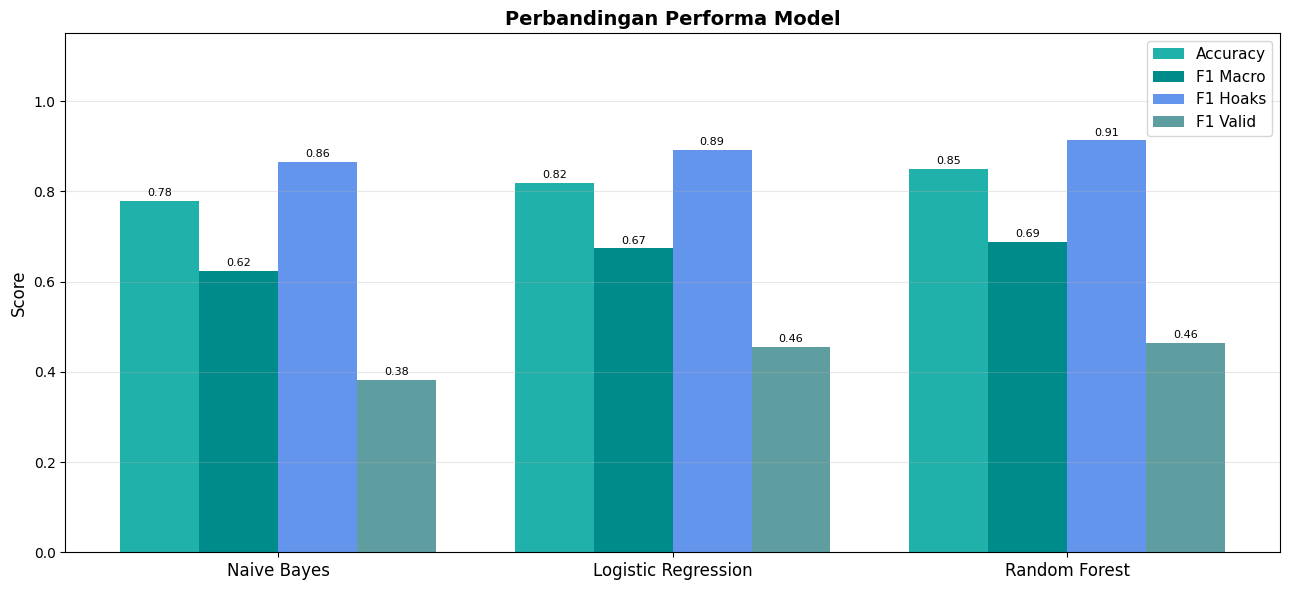

In [20]:
import numpy as np
nama_model = list(hasil_model.keys())
f1_macro   = [hasil_model[m]['f1_macro']  for m in nama_model]
f1_hoaks   = [hasil_model[m]['f1_hoaks']  for m in nama_model]
f1_valid   = [hasil_model[m]['f1_valid']  for m in nama_model]
akurasi    = [hasil_model[m]['accuracy']  for m in nama_model]

x     = np.arange(len(nama_model))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width*1.5, akurasi,  width, label='Accuracy', color='lightseagreen')
ax.bar(x - width*0.5, f1_macro, width, label='F1 Macro', color='darkcyan')
ax.bar(x + width*0.5, f1_hoaks, width, label='F1 Hoaks', color='cornflowerblue')
ax.bar(x + width*1.5, f1_valid, width, label='F1 Valid', color='cadetblue')

ax.set_xticks(x)
ax.set_xticklabels(nama_model, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE IMPORTANCE - RANDOM FOREST (Model Terbaik)


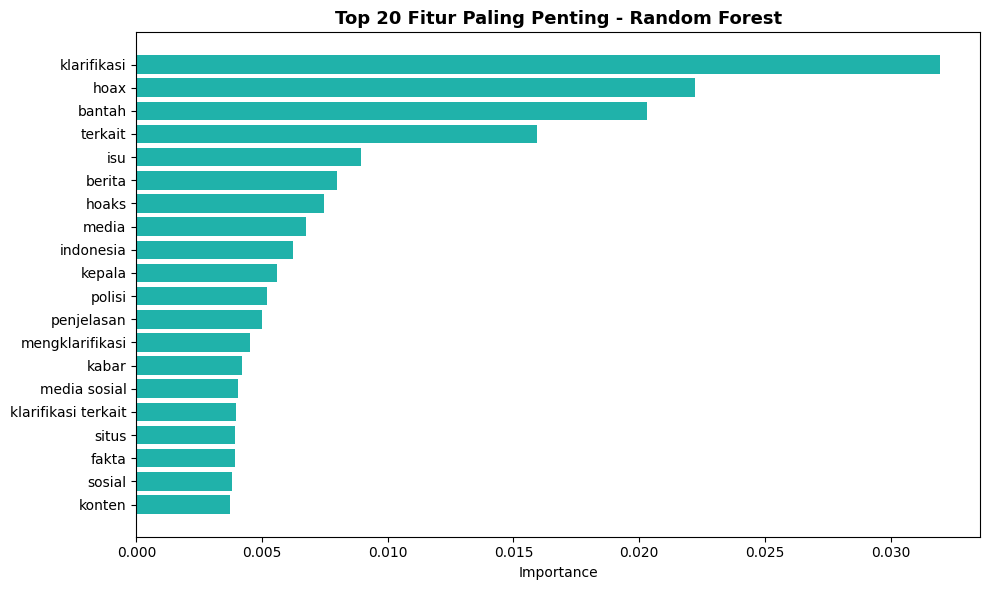

INDIKASI FITUR PER KELAS - LOGISTIC REGRESSION (Untuk Interpretasi)


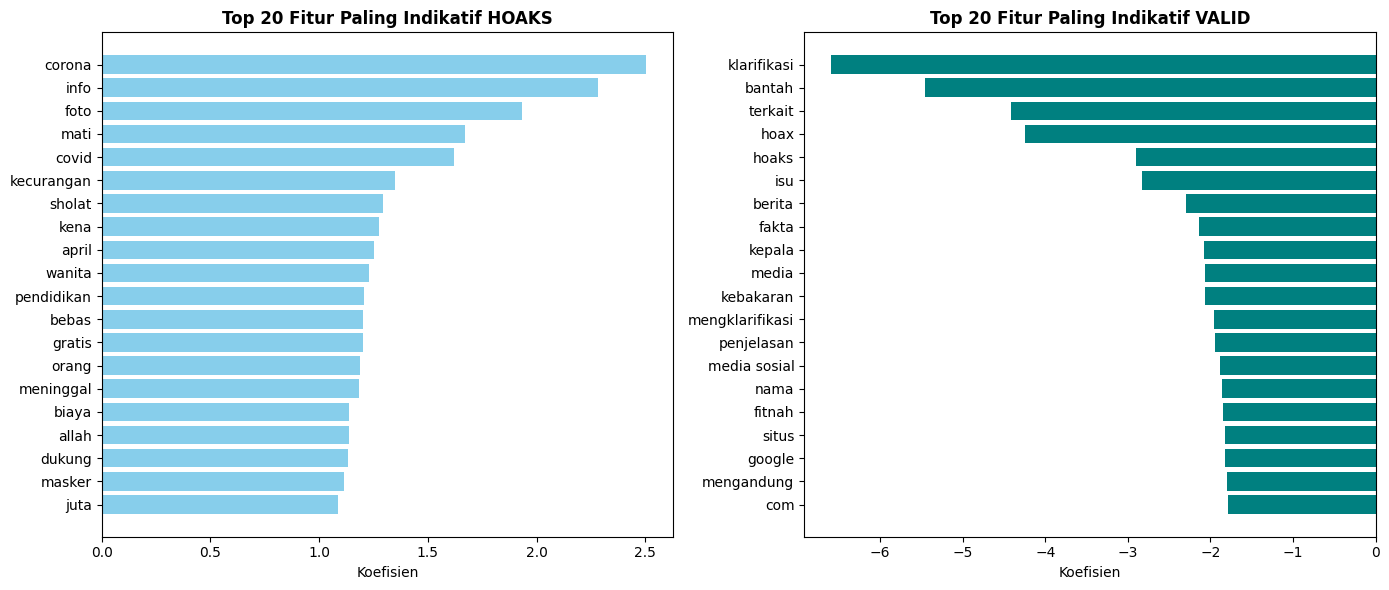

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

model_terbaik_nama = max(hasil_model, key=lambda m: hasil_model[m]['f1_macro'])
model_terbaik      = hasil_model[model_terbaik_nama]['model']

print("FEATURE IMPORTANCE - RANDOM FOREST (Model Terbaik)")

if model_terbaik_nama == 'Random Forest':
    importances = model_terbaik.feature_importances_
    feature_names = tfidf.get_feature_names_out()

    if len(importances) > len(feature_names):
        importances = importances[:len(feature_names)]
    elif len(importances) < len(feature_names):
        feature_names = feature_names[:len(importances)]

    indices = np.argsort(importances)[::-1][:20]
    top_features = [(feature_names[i], importances[i]) for i in indices]

    plt.figure(figsize=(10, 6))
    plt.barh([f[0][:40] for f in top_features[::-1]],
             [f[1] for f in top_features[::-1]],
             color='lightseagreen')
    plt.xlabel('Importance')
    plt.title('Top 20 Fitur Paling Penting - Random Forest', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Model terbaik adalah {model_terbaik_nama}, bukan Random Forest.\n")

print("INDIKASI FITUR PER KELAS - LOGISTIC REGRESSION (Untuk Interpretasi)")

# Latih ulang Logistic Regression pada data yang sama untuk interpretasi
lr_for_interpretasi = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_for_interpretasi.fit(X_train_smote, y_train_smote)

coef = lr_for_interpretasi.coef_[0]
feature_names = tfidf.get_feature_names_out()

if len(coef) > len(feature_names):
    coef = coef[:len(feature_names)]
elif len(coef) < len(feature_names):
    feature_names = feature_names[:len(coef)]

sorted_indices = coef.argsort()
top_hoaks_idx = sorted_indices[-20:][::-1]
top_valid_idx = sorted_indices[:20]

top_hoaks = [(feature_names[i], coef[i]) for i in top_hoaks_idx]
top_valid = [(feature_names[i], coef[i]) for i in top_valid_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([w[0][:30] for w in top_hoaks[::-1]],
             [w[1] for w in top_hoaks[::-1]],
             color='skyblue')
axes[0].set_title('Top 20 Fitur Paling Indikatif HOAKS', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Koefisien')

axes[1].barh([w[0][:30] for w in top_valid[::-1]],
             [w[1] for w in top_valid[::-1]],
             color='teal')
axes[1].set_title('Top 20 Fitur Paling Indikatif VALID', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Koefisien')

plt.tight_layout()
plt.savefig('feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pilih model dengan F1 Macro tertinggi
model_terbaik_nama = max(hasil_model, key=lambda m: hasil_model[m]['f1_macro'])
model_terbaik      = hasil_model[model_terbaik_nama]['model']
y_pred_terbaik     = hasil_model[model_terbaik_nama]['y_pred']

# Classification report lengkap model terpilih
print(f"Model terpilih: {model_terbaik_nama}\n")
print(classification_report(y_val, y_pred_terbaik, target_names=['Valid (0)', 'Hoaks (1)']))

Model terpilih: Random Forest

              precision    recall  f1-score   support

   Valid (0)       0.65      0.36      0.46       153
   Hoaks (1)       0.87      0.96      0.91       694

    accuracy                           0.85       847
   macro avg       0.76      0.66      0.69       847
weighted avg       0.83      0.85      0.83       847



## Pemilihan Model Terbaik
Model dengan F1 Macro tertinggi dipilih sebagai model final untuk prediksi data uji, sehingga model yang terpilih adalah Logistic Regression.

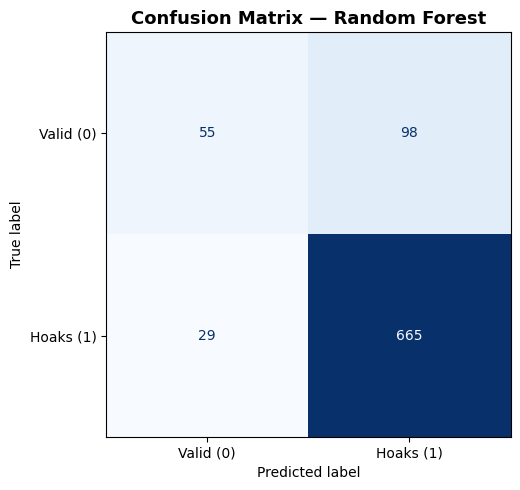

In [25]:
# Confusion matrix model terpilih
fig, ax = plt.subplots(figsize=(7, 5))
cm      = confusion_matrix(y_val, y_pred_terbaik)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Valid (0)', 'Hoaks (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {model_terbaik_nama}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
THRESHOLD = best_thresh

y_prob_uji = model_terbaik.predict_proba(X_uji_tfidf)
prob_hoaks = y_prob_uji[:, 1]
prob_valid = y_prob_uji[:, 0]

y_pred_uji = (prob_hoaks >= THRESHOLD).astype(int)

df_uji['prediksi_label'] = y_pred_uji
df_uji['prob_hoaks'] = np.round(prob_hoaks * 100, 2)
df_uji['prob_valid'] = np.round(prob_valid * 100, 2)
df_uji['keterangan'] = df_uji['prediksi_label'].map({1: 'HOAKS', 0: 'VALID'})

print("Distribusi prediksi data uji:")
print(df_uji['keterangan'].value_counts())
print()
df_uji[['ID', 'judul', 'keterangan', 'prob_hoaks', 'prob_valid']].head(10)

Distribusi prediksi data uji:
keterangan
HOAKS    412
VALID     58
Name: count, dtype: int64



,ID,judul,keterangan,prob_hoaks,prob_valid
0,238057,Narasi Tito Karnavian Berideologi Komunis Kare...,HOAKS,92.0,8.0
1,238158,Anies: Seberat beratnya Pekerjaan Akan terasa ...,HOAKS,96.0,4.0
2,238865,Hindu di india Melemparkan Patung Buatan Merek...,HOAKS,94.0,6.0
3,248298,RSCM Praktekkan Penyedotan Plug Vena/Saluran ...,HOAKS,88.0,12.0
4,255176,Permohonan Kelonggaran Angsuran ke OJK,HOAKS,85.5,14.5
5,267051,Aksi BEM se-Jabotabek hari ini,HOAKS,85.5,14.5
6,269336,Sinar Kosmik Berbahaya Radiasi,VALID,42.0,58.0
7,272438,Pihak SMKN 12 Beri Klarifikasi Perihal Kabar V...,VALID,34.5,65.5
8,282152,Pembuatan KTP Orang Gila Demi Ambisi Kekuasaan,HOAKS,88.0,12.0
9,288490,Daniel Radcliffe Positiv Terinfeksi Corona Cov...,HOAKS,93.5,6.5


In [27]:
metadata = {
    'model_name' : model_terbaik_nama,
    'accuracy'   : round(hasil_model[model_terbaik_nama]['accuracy'], 4),
    'f1_macro'   : round(hasil_model[model_terbaik_nama]['f1_macro'], 4),
    'f1_hoaks'   : round(hasil_model[model_terbaik_nama]['f1_hoaks'], 4),
    'f1_valid'   : round(hasil_model[model_terbaik_nama]['f1_valid'], 4),
    'vocab_size' : len(tfidf.vocabulary_),
    'threshold'  : 0.70,
    'all_results': {
        nama: {
            'accuracy': round(v['accuracy'], 4),
            'f1_macro': round(v['f1_macro'], 4),
            'f1_hoaks': round(v['f1_hoaks'], 4),
            'f1_valid': round(v['f1_valid'], 4),
        } for nama, v in hasil_model.items()
    }
}

In [28]:
import joblib

joblib.dump({
    'model': model_terbaik,
    'tfidf': tfidf,
    'threshold': best_thresh
}, 'model_hoaks_with_thresh.pkl')

['model_hoaks_with_thresh.pkl']

In [30]:
from google.colab import files
files.download('model_hoaks_with_thresh.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>